<a href="https://colab.research.google.com/github/stephenchen0814/04-LinearReg_Salary/blob/main/Model%20Evaluation%2C%20Cross-Validation%2C%20GridSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd

from matplotlib.patches import Patch
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset=datasets.load_breast_cancer()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [3]:
model = DecisionTreeClassifier(criterion="gini", min_impurity_decrease=.01, min_samples_leaf=5,max_depth=3,max_features=5)
model.fit(X_train, y_train)
predictions =model.predict(X_test)

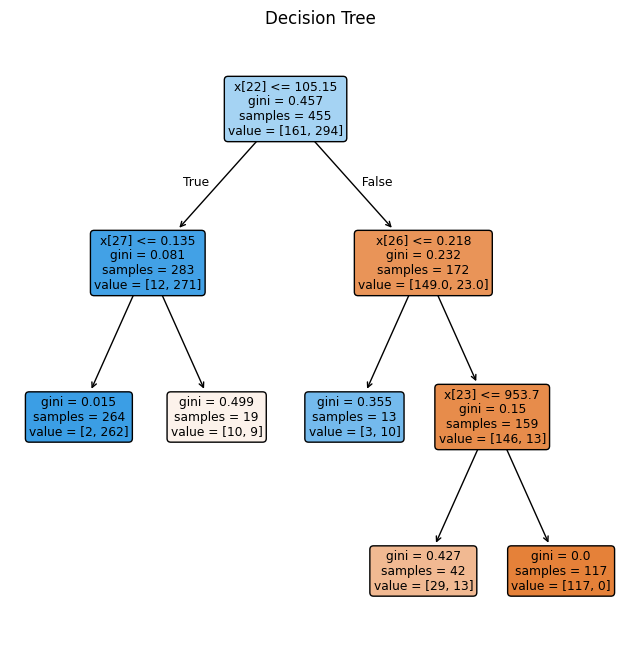

In [4]:
plt.figure(figsize=(8, 8))
plot_tree(model, filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

In [5]:
print('Confusion Matrix = \n',confusion_matrix(y_test, predictions))
print('Accuracy =',accuracy_score(y_test, predictions))
print('Precision =',precision_score(y_test, predictions))
print('Recall =',recall_score(y_test, predictions))
print('F1 score =',f1_score(y_test, predictions))
fpr, tpr, thresholds = roc_curve(y_test, predictions)
print('AUC = ',auc(fpr, tpr) )

Confusion Matrix = 
 [[47  4]
 [ 8 55]]
Accuracy = 0.8947368421052632
Precision = 0.9322033898305084
Recall = 0.873015873015873
F1 score = 0.9016393442622951
AUC =  0.8972922502334267


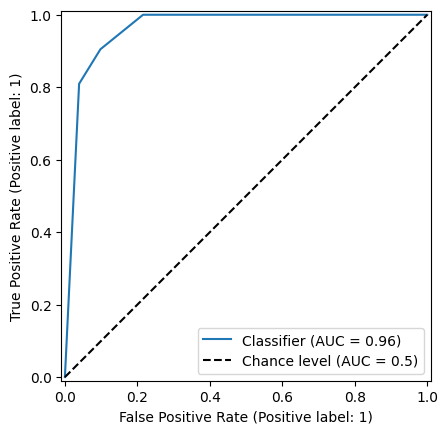

In [6]:
prob=model.predict_proba(X_test)[:,1]
RocCurveDisplay.from_predictions(y_test, prob,plot_chance_level=True)
plt.show()

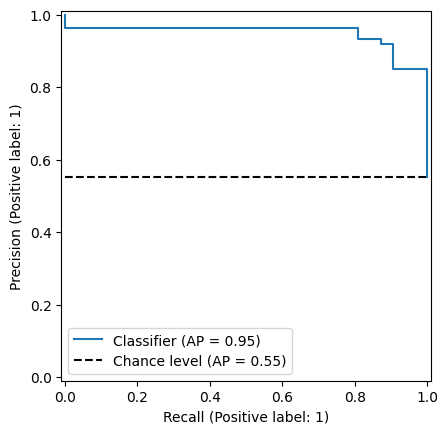

In [7]:
PrecisionRecallDisplay.from_predictions(y_test, prob, plot_chance_level=True)
plt.show()

In [8]:
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

def plot_cv_indices(cv, X, y, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""

    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=None)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes and groups at the end
    ax.scatter(range(len(X)), [ii + 1.5] * len(X),
               c=y, marker='_', lw=lw, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ['class']
    ax.set(yticks=np.arange(n_splits+1) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="CV iteration",
           ylim=[n_splits+1.2, -.1], xlim=[0, X.shape[0]])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

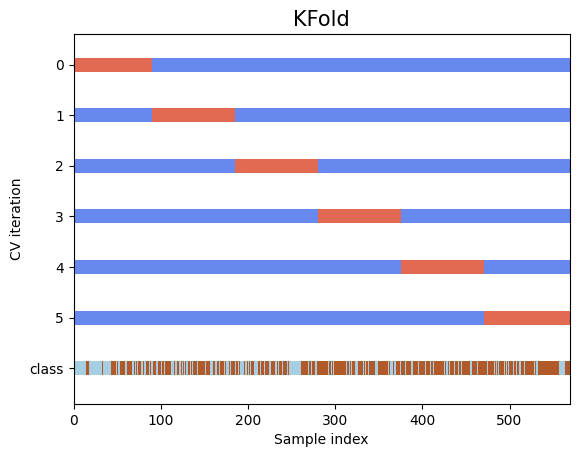

In [18]:
n_splits = 6
cv = KFold(n_splits)

fig, ax = plt.subplots()
plot_cv_indices(cv, X, y, ax, n_splits)
plt.show()

In [10]:
scores=cross_val_score(model, X_train, y_train, cv=5)
scores

array([0.92307692, 0.9010989 , 0.92307692, 0.91208791, 0.93406593])

In [11]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

0.92 accuracy with a standard deviation of 0.01


In [12]:
fscores=cross_val_score(model, X_train, y_train, cv=5,scoring='f1_macro')
fscores

array([0.97553763, 0.82051282, 0.94094744, 0.92868339, 0.89230769])

In [13]:
print("%0.2f f1-score with a standard deviation of %0.2f" % (fscores.mean(), fscores.std()))

0.91 f1-score with a standard deviation of 0.05


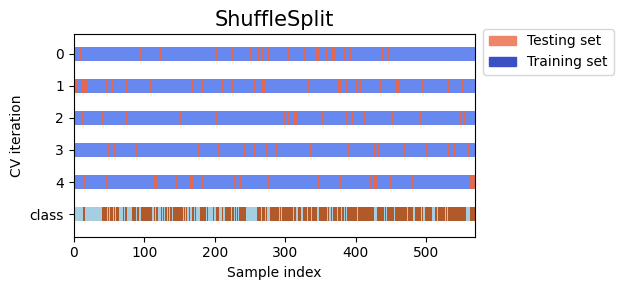

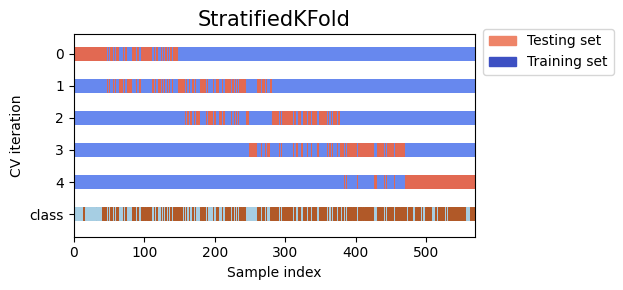

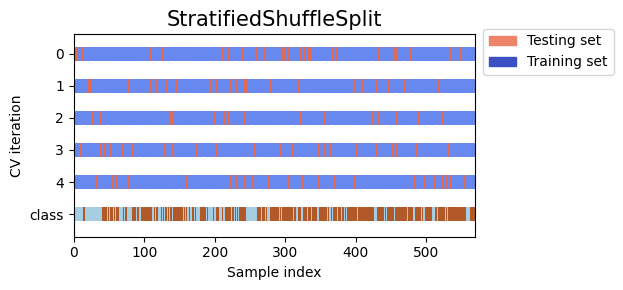

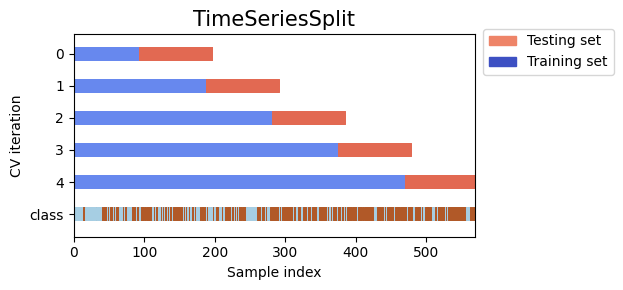

In [17]:
cvs = [
    ShuffleSplit,
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit]

for cv in cvs:
    this_cv = cv(n_splits=n_splits)
    fig, ax = plt.subplots(figsize=(6, 3))
    plot_cv_indices(this_cv, X, y, ax, n_splits)

    ax.legend(
        [Patch(color=cmap_cv(0.8)), Patch(color=cmap_cv(0.01))],
        ["Testing set", "Training set"],
        loc=(1.02, 0.8),
    )
    # Make the legend fit
    plt.tight_layout()
    fig.subplots_adjust(right=0.8)
plt.show()

In [19]:
param_dist  = {
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [2,3,4, 5, 6],
              'criterion' :['gini', 'entropy'],
              'min_impurity_decrease' : [0.01, 0.05, 0.1]
             }

In [22]:
model = DecisionTreeClassifier()
tree_cv = GridSearchCV(model, param_dist, cv=4)

tree_cv.fit(X, y)
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 3, 'min_impurity_decrease': 0.01}
Best score is 0.9455087166354772


In [23]:
models_list = [LogisticRegression(max_iter=1000), SVC(), DecisionTreeClassifier()]

model_hyperparameters = {
    'log_reg_hyperparameters': {
        'C' : [1,5,10,20] },

    'svc_hyperparameters': {
        'kernel' : ['linear','poly','rbf','sigmoid'],
        'C' : [1,5,10,20] },

    'random_forest_hyperparameters' : {
        'criterion' :['gini', 'entropy'],
         'max_depth' : [2,3,4, 5, 6] }
}

model_keys = list(model_hyperparameters.keys())

In [26]:
def ModelSelection(list_of_models, hyperparameters_dictionary, random=False):
  result = []
  i = 0

  for model in list_of_models:
    key = model_keys[i]
    params = hyperparameters_dictionary[key]
    i += 1
    print(model)
    print(params)
    print('---------------------------------')
    if random:
        classifier = RandomizedSearchCV(model, params, cv=4)
    else:
        classifier = GridSearchCV(model, params, cv=4)
    # fitting the data to classifier
    classifier.fit(X,y)
    result.append({
        'model used' : model,
        'highest score' : classifier.best_score_,
        'best hyperparameters' : classifier.best_params_
    })

  result_dataframe = pd.DataFrame(result, columns = ['model used','highest score','best hyperparameters'])

  return result_dataframe

In [27]:
ModelSelection(models_list, model_hyperparameters)

LogisticRegression(max_iter=1000)
{'C': [1, 5, 10, 20]}
---------------------------------
SVC()
{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'C': [1, 5, 10, 20]}
---------------------------------
DecisionTreeClassifier()
{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 4, 5, 6]}
---------------------------------


,model used,highest score,best hyperparameters
0,LogisticRegression(max_iter=1000),0.950827,{'C': 10}
1,SVC(),0.947282,"{'C': 20, 'kernel': 'linear'}"
2,DecisionTreeClassifier(),0.945509,"{'criterion': 'entropy', 'max_depth': 3}"


In [28]:
ModelSelection(models_list, model_hyperparameters, random=True)

LogisticRegression(max_iter=1000)
{'C': [1, 5, 10, 20]}
---------------------------------
SVC()
{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'C': [1, 5, 10, 20]}
---------------------------------
DecisionTreeClassifier()
{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 4, 5, 6]}
---------------------------------


,model used,highest score,best hyperparameters
0,LogisticRegression(max_iter=1000),0.950827,{'C': 10}
1,SVC(),0.947282,"{'kernel': 'linear', 'C': 20}"
2,DecisionTreeClassifier(),0.945509,"{'max_depth': 3, 'criterion': 'entropy'}"
